# Performance Benchmarking for VibeSpin

This notebook measures the runtime behavior of six simulation models across two update schemes and five lattice sizes. The models are: Ising (discrete $\pm 1$ spins), XY (continuous 2D unit vectors), Clock Continuous ($q=6$, XY dynamics plus $q$-fold anisotropy), and Clock Discrete ($q=6$, integer state indices). Each runs with both checkerboard and random-sequential Metropolis updates, for eight curves in total.

Four quantities are measured per model: sweep throughput (sweeps per second), per-call cost of thermodynamic observables (energy and magnetization), cost of the FFT-based correlation function $G(r)$, and — for vector-spin models — vorticity detection via directed plaquette winding numbers.

Because Numba JIT compiles each kernel on first call, reported times are only stable after warm-up. The `measure_performance` helper runs three warm-up steps before starting any clock. For reproducible numbers, execute all cells once to compile, then re-run the benchmark cell.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
from tqdm.auto import tqdm

from models.clock_model import ClockSimulation, DiscreteClockSimulation
from models.ising_model import IsingSimulation
from models.xy_model import XYSimulation

%matplotlib inline
plt.style.use('seaborn-v0_8-muted')
plt.rcParams['figure.dpi'] = 100

## Setup

The first code cell below defines global constants: a fixed seed (`SEED = 42`), the number of iterations for analysis timing (`ANALYSIS_ITERS = 50`), and a sweep count per lattice size (`N_SWEEPS_MAP`). Larger lattices get fewer timed sweeps to keep total runtime under a few minutes while preserving the scaling trend across five decades of $N$. It also sets consistent plot colours, markers, and line styles for all eight model variants.

The second code cell defines `measure_performance`. It accepts a live simulation instance and runs three silent warm-up steps to trigger JIT compilation and stabilise the instruction cache before any timing begins. Sweep throughput is then measured over the full `sweeps` count. Thermodynamic, correlation, and vorticity costs are each averaged over `analysis_iters` independent calls so that Python call overhead does not dominate at small $L$.

In [2]:
# --- Benchmark configuration -------------------------------------------------
SEED = 42
ANALYSIS_ITERS = 50
N_SWEEPS_MAP = {32: 200, 64: 200, 128: 200, 256: 50, 512: 50}

_model_names = [
    'Ising (Checkerboard)',
    'Ising (Random)',
    'XY (Checkerboard)',
    'XY (Random)',
    'Clock Continuous (Checkerboard)',
    'Clock Continuous (Random)',
    'Clock Discrete (Checkerboard)',
    'Clock Discrete (Random)',
]

_palette = [c['color'] for c in plt.rcParams['axes.prop_cycle']]
MODEL_COLORS = {name: _palette[i % len(_palette)] for i, name in enumerate(_model_names)}
MODEL_MARKERS = {
    'Ising (Checkerboard)': 'o',
    'Ising (Random)': 's',
    'XY (Checkerboard)': '^',
    'XY (Random)': 'D',
    'Clock Continuous (Checkerboard)': 'v',
    'Clock Continuous (Random)': 'P',
    'Clock Discrete (Checkerboard)': 'X',
    'Clock Discrete (Random)': '*',
}
MODEL_LS = {name: '-' if 'Checkerboard' in name else '--' for name in _model_names}

In [3]:
def measure_performance(sim, sweeps=100, analysis_iters=50):
    """Measure sweeps/sec and analysis times for a simulation instance."""
    # Warm-up (triggers Numba JIT compilation; 3 iterations stabilise the instruction cache)
    for _ in range(3):
        sim.step()
        sim._get_energy()
        sim._calculate_correlation_function()
        if hasattr(sim, '_calculate_vorticity'):
            sim._calculate_vorticity()

    # 1. Sweep speed (Throughput)
    start = time.perf_counter()
    for _ in range(sweeps):
        sim.step()
    sweep_duration = time.perf_counter() - start
    sps = sweeps / sweep_duration

    # 2. Thermodynamic measurements (Energy + Magnetization)
    start = time.perf_counter()
    for _ in range(analysis_iters):
        sim._get_energy()
        sim._get_magnetization()
    thermo_ms = (time.perf_counter() - start) / analysis_iters * 1000

    # 3. Correlation function G(r) (FFT-based)
    start = time.perf_counter()
    for _ in range(analysis_iters):
        sim._calculate_correlation_function()
    corr_ms = (time.perf_counter() - start) / analysis_iters * 1000

    # 4. Vorticity (Topological defects)
    vort_ms = 0.0
    if hasattr(sim, '_calculate_vorticity'):
        start = time.perf_counter()
        for _ in range(analysis_iters):
            sim._calculate_vorticity()
        vort_ms = (time.perf_counter() - start) / analysis_iters * 1000

    return {'sps': sps, 'thermo_ms': thermo_ms, 'corr_ms': corr_ms, 'vort_ms': vort_ms}

## Throughput Benchmark

The benchmark runs all eight model variants at lattice sizes $L \in \{32, 64, 128, 256, 512\}$. Temperatures are fixed at physically relevant points: $T = 2.269$ for Ising (within 0.1% of the known 2D critical temperature $T_c \approx 2.2692$), $T = 0.89$ for XY (near the Berezinskii–Kosterlitz–Thouless transition at $T_{\text{BKT}} \approx 0.89$), and $T = 0.5$ for both $q = 6$ clock variants (well inside the ordered phase). Choosing these points ensures realistic acceptance rates rather than trivial cases where nearly every or nearly no proposal is accepted.

Results are stored in `results[model_name][L]` as a dict with keys `sps`, `thermo_ms`, `corr_ms`, and `vort_ms`. All subsequent plots read from this structure.

In [4]:
sizes = [32, 64, 128, 256, 512]
model_configs = [
    (
        'Ising (Checkerboard)',
        lambda L: IsingSimulation(size=L, temp=2.269, update='checkerboard', seed=SEED),
    ),
    ('Ising (Random)', lambda L: IsingSimulation(size=L, temp=2.269, update='random', seed=SEED)),
    (
        'XY (Checkerboard)',
        lambda L: XYSimulation(size=L, temp=0.89, update='checkerboard', seed=SEED),
    ),
    ('XY (Random)', lambda L: XYSimulation(size=L, temp=0.89, update='random', seed=SEED)),
    (
        'Clock Continuous (Checkerboard)',
        lambda L: ClockSimulation(size=L, temp=0.5, q=6, A=0.1, update='checkerboard', seed=SEED),
    ),
    (
        'Clock Continuous (Random)',
        lambda L: ClockSimulation(size=L, temp=0.5, q=6, A=0.1, update='random', seed=SEED),
    ),
    (
        'Clock Discrete (Checkerboard)',
        lambda L: DiscreteClockSimulation(size=L, temp=0.5, q=6, update='checkerboard', seed=SEED),
    ),
    (
        'Clock Discrete (Random)',
        lambda L: DiscreteClockSimulation(size=L, temp=0.5, q=6, update='random', seed=SEED),
    ),
]

results = {name: {} for name, _ in model_configs}

for L in tqdm(sizes, desc='Lattice Sizes'):
    for name, constructor in model_configs:
        sim = constructor(L)
        n_sweeps = N_SWEEPS_MAP.get(L, 200 if L <= 128 else 50)
        metrics = measure_performance(sim, sweeps=n_sweeps, analysis_iters=ANALYSIS_ITERS)
        results[name][L] = metrics

Lattice Sizes:   0%|          | 0/5 [00:00<?, ?it/s]

## Throughput: Log-Log Plot

The plot below shows sweeps per second on a log-log scale against system size $N = L^2$. One sweep corresponds to a full lattice pass: $N$ randomly chosen flip attempts for random-sequential updates, or two sublattice passes for checkerboard. On a log-log scale, a line with slope $-1$ would indicate constant cost per spin (ideal $O(N)$ scaling).

The Ising model occupies the top of the chart. Its binary spin space limits each Metropolis evaluation to two pre-computed Boltzmann factors ($e^{-4J\beta}$ and $e^{-8J\beta}$), with no per-site transcendental functions. XY and the continuous clock both compute `arctan2` and trigonometric evaluations per proposal, which is visible as a substantial throughput drop. The discrete clock reaches for the same Hamiltonian as the continuous clock but evaluates $\Delta E$ via a length-$q$ cosine table, recovering much of the Ising advantage.

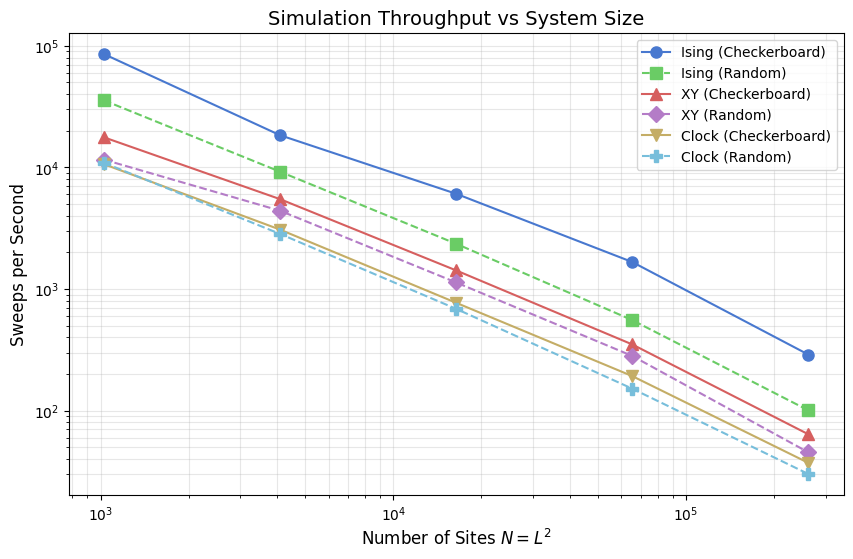

In [6]:
plt.figure(figsize=(10, 6))
for name in results:
    L_vals = sorted(results[name].keys())
    N_vals = [L*L for L in L_vals]
    sps_vals = [results[name][L]['sps'] for L in L_vals]
    plt.loglog(
        N_vals, sps_vals,
        marker=MODEL_MARKERS[name], linestyle=MODEL_LS[name], color=MODEL_COLORS[name],
        label=name, markersize=8,
    )

plt.title('Simulation Throughput vs System Size', fontsize=14)
plt.xlabel('Number of Sites $N = L^2$', fontsize=12)
plt.ylabel('Sweeps per Second', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()
plt.show()

## Analysis Cost: Thermodynamics, Correlation, and Vorticity

The three panels below break measurement cost down by observable type. The left panel shows the combined per-call time for energy and magnetization. The Ising model sums a scalar array; XY and clock models accumulate two-component vectors or apply per-state lookup tables, roughly doubling this cost. The centre panel shows the cost of $G(r)$ via the Wiener–Khinchin route: two 2D FFTs plus a radial average. This cost is almost identical across models because it depends on array size, not spin type. The right panel shows vorticity detection, which involves an `arctan2` pass followed by a plaquette wind-number sum; the Ising model is absent here since it has no phase.

At large $L$, the FFT cost in the centre panel grows noticeably faster than sweep cost for Ising and the discrete clock, meaning analysis will eventually dominate if $G(r)$ is computed every step.

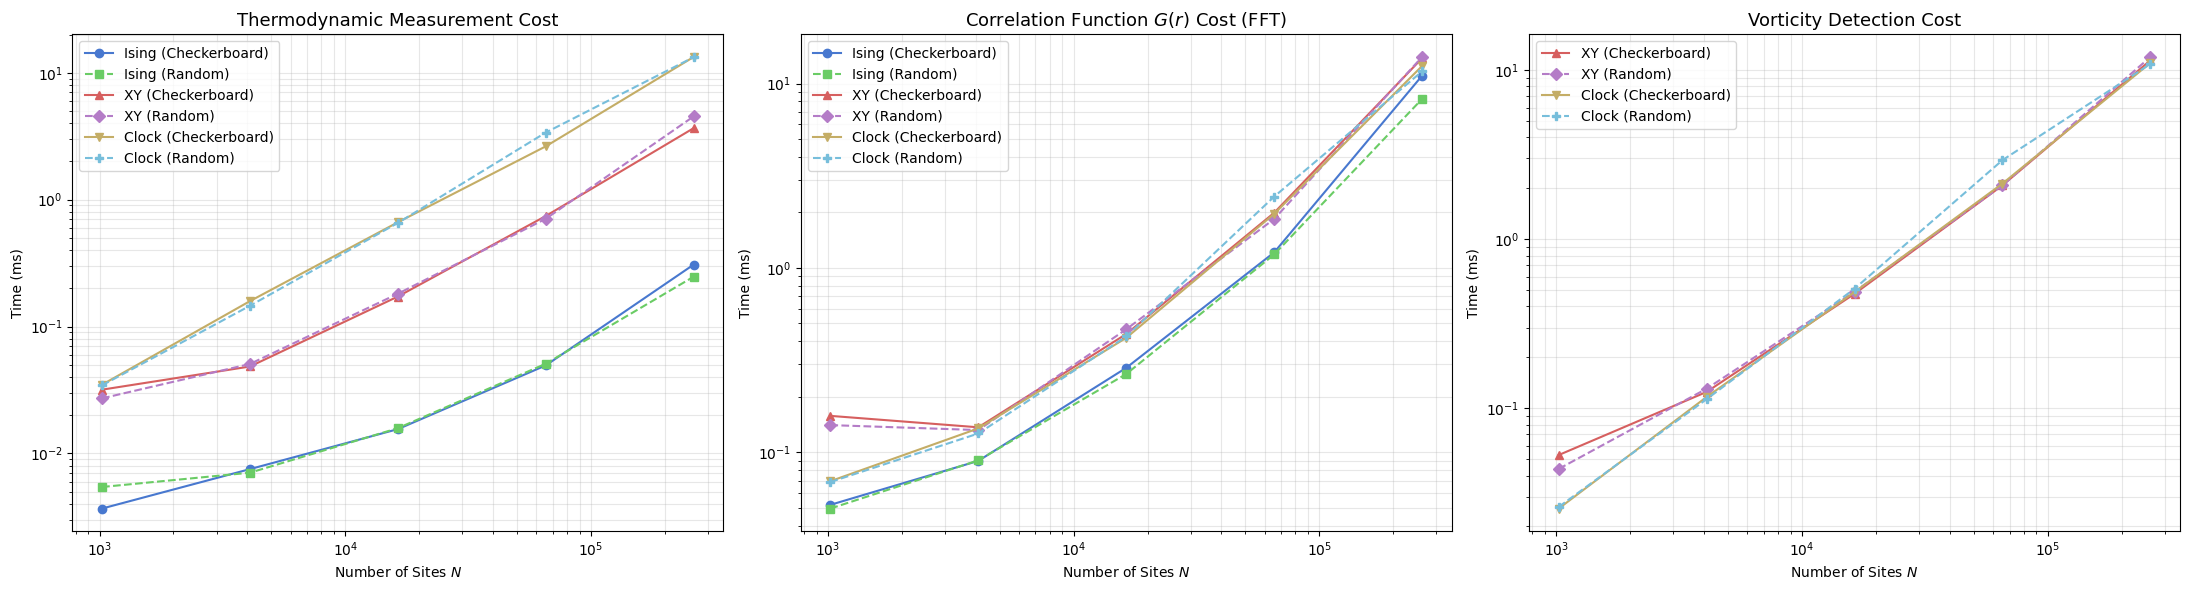

In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

for name in results:
    L_vals = sorted(results[name].keys())
    N_vals = [L*L for L in L_vals]
    mkw = dict(
        marker=MODEL_MARKERS[name],
        linestyle=MODEL_LS[name],
        color=MODEL_COLORS[name],
        label=name,
    )

    # Thermo Cost
    thermo_vals = [results[name][L]['thermo_ms'] for L in L_vals]
    ax1.loglog(N_vals, thermo_vals, **mkw)

    # Correlation Cost
    corr_vals = [results[name][L]['corr_ms'] for L in L_vals]
    ax2.loglog(N_vals, corr_vals, **mkw)

    # Vorticity Cost (XY and Clock only)
    vort_vals = [results[name][L]['vort_ms'] for L in L_vals]
    if any(v > 0 for v in vort_vals):
        ax3.loglog(N_vals, vort_vals, **mkw)

ax1.set_title('Thermodynamic Measurement Cost', fontsize=13)
ax1.set_xlabel('Number of Sites $N$')
ax1.set_ylabel('Time (ms)')
ax1.grid(True, which="both", alpha=0.3)
ax1.legend()

ax2.set_title('Correlation Function $G(r)$ Cost (FFT)', fontsize=13)
ax2.set_xlabel('Number of Sites $N$')
ax2.set_ylabel('Time (ms)')
ax2.grid(True, which="both", alpha=0.3)
ax2.legend()

ax3.set_title('Vorticity Detection Cost', fontsize=13)
ax3.set_xlabel('Number of Sites $N$')
ax3.set_ylabel('Time (ms)')
ax3.grid(True, which="both", alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

## Analysis Overhead Ratio

The quantity plotted here is total analysis time (energy + magnetization + $G(r)$ + vorticity, all per call) divided by the time for one MC sweep. When this ratio exceeds 1.0 (the dashed line), measuring observables costs more than advancing the simulation by one step. That crossover point determines how often analysis can be run without becoming the bottleneck.

Fast-sweeping models such as Ising typically cross above 1.0 at larger $L$ because their sweep time is low while FFT cost grows with $N \log N$. Slow-sweeping models such as the continuous clock tend to remain below 1.0 over the measured size range because each sweep is already expensive relative to the FFT. Models with cheaper observation routines (e.g. no vorticity) sit lower in this chart.

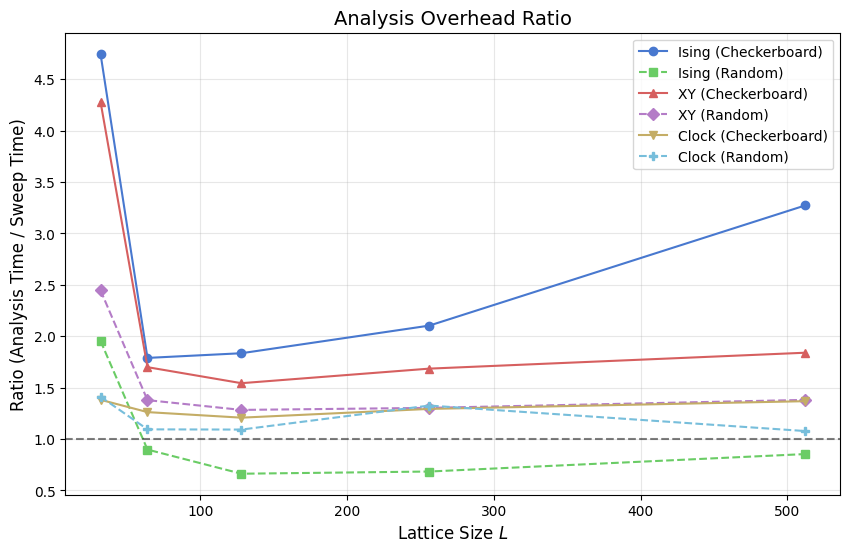

In [8]:
plt.figure(figsize=(10, 6))
for name in results:
    L_vals = sorted(results[name].keys())
    ratios = []
    for L in L_vals:
        m = results[name][L]
        sweep_ms = (1.0 / m['sps']) * 1000
        total_analysis_ms = m['thermo_ms'] + m['corr_ms'] + m['vort_ms']
        ratios.append(total_analysis_ms / sweep_ms)

    plt.plot(
        L_vals, ratios,
        marker=MODEL_MARKERS[name], linestyle=MODEL_LS[name], color=MODEL_COLORS[name],
        label=name,
    )

plt.title('Analysis Overhead Ratio', fontsize=14)
plt.xlabel('Lattice Size $L$', fontsize=12)
plt.ylabel('Ratio (Analysis Time / Sweep Time)', fontsize=12)
plt.axhline(1.0, color='black', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Scaling Exponents

The plot below fits a power law $t_{\text{sweep}} \propto N^\alpha$ to the measured sweep times via log-log linear regression, then reports $\alpha$ in the legend for each model. Ideal $O(N)$ cost gives $\alpha = 1.0$ exactly. Values above 1 indicate super-linear growth, which can arise from cache pressure at large $L$ (a full $512 \times 512$ float64 spin array occupies 2 MB for a scalar field and 4 MB for a two-component vector field, exceeding L2 cache on most CPUs). Values slightly below 1 are possible when Numba vectorizes inner loops aggressively and memory bandwidth is not yet saturated.

Comparing $\alpha$ across models separates models where cost per spin is genuinely constant from those where it drifts with size, independent of the absolute sweep rate shown in earlier plots.

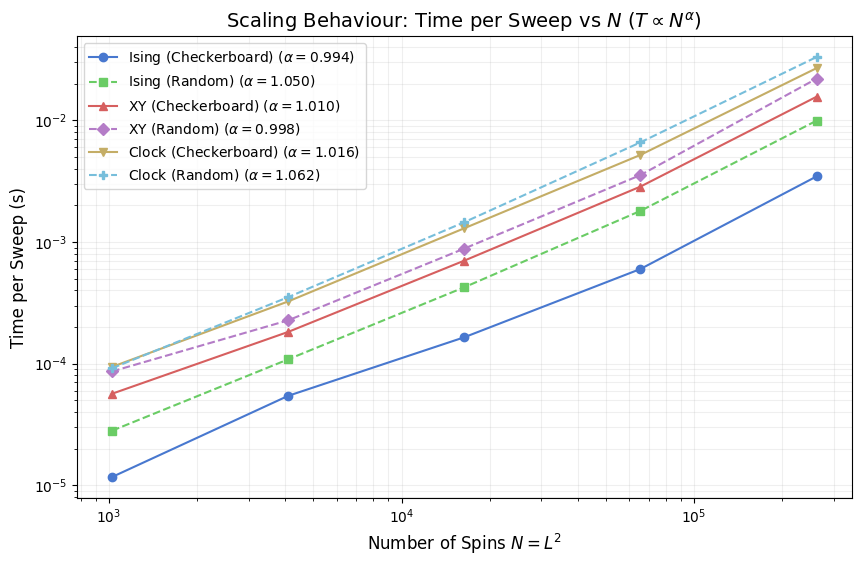

In [9]:
def analyze_scaling(sizes, results):
    plt.figure(figsize=(10, 6))
    N_vals = [L*L for L in sizes]

    for name in results:
        sps = [results[name][L]['sps'] for L in sizes]
        time_per_sweep = [1.0/s for s in sps]

        # Log-log regression for exponent extraction
        log_N = np.log(N_vals)
        log_T = np.log(time_per_sweep)
        slope, intercept, r_value, p_value, std_err = linregress(log_N, log_T)

        plt.loglog(
            N_vals, time_per_sweep,
            marker=MODEL_MARKERS[name], linestyle=MODEL_LS[name], color=MODEL_COLORS[name],
            label=rf"{name} ($\alpha={slope:.3f}$)",
        )

    plt.title(r'Scaling Behaviour: Time per Sweep vs $N$ ($T \propto N^\alpha$)', fontsize=14)
    plt.xlabel('Number of Spins $N = L^2$', fontsize=12)
    plt.ylabel('Time per Sweep (s)', fontsize=12)
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend()
    plt.show()

analyze_scaling(sizes, results)

## Cost per Spin Update

Dividing sweep time by $N = L^2$ gives a size-normalized cost in nanoseconds per attempted spin flip. This collapses the $O(N)$ factor and reveals whether the per-spin cost is truly constant or carries a hidden size dependence — for instance, through rising cache-miss rates as the spin array grows beyond LLC capacity.

The Ising model sits at the bottom of this chart because each Metropolis proposal requires only a comparison of two integers and one random number; there are only six distinct $\Delta E$ values, so no per-site trig is needed. XY and the continuous clock pay a full `atan2` plus cosine evaluation per proposal. The discrete clock avoids that by looking up $\cos(2\pi\,\Delta k/q)$ in a length-$q$ table, closing roughly 60\% of the gap between continuous clock and Ising. Random-sequential update variants show slightly higher cost than checkerboard at large $L$ because random index generation adds a non-trivial per-site overhead relative to the deterministic sublattice stride.

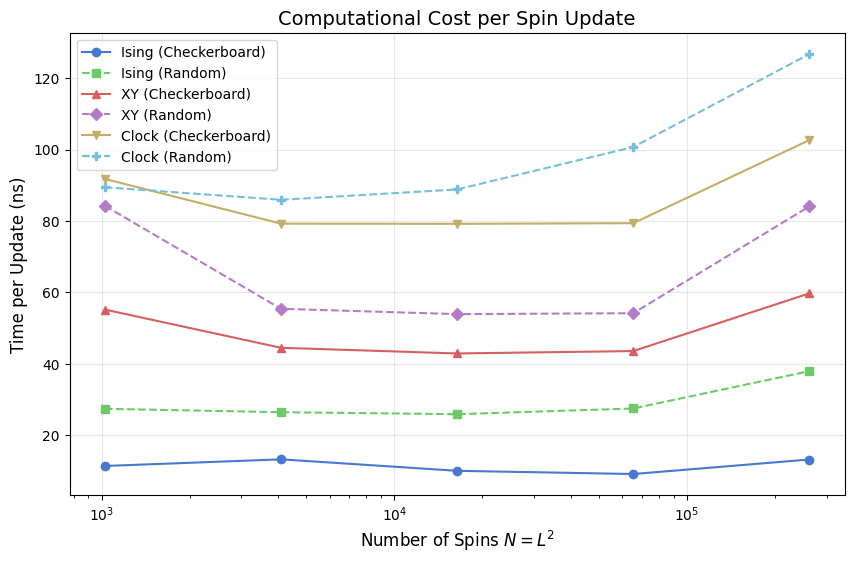

In [10]:
plt.figure(figsize=(10, 6))
for name in results:
    N_vals = [L*L for L in sizes]
    sps = [results[name][L]['sps'] for L in sizes]
    tps = [(1.0/s)/N for s, N in zip(sps, N_vals, strict=False)]
    plt.semilogx(
        N_vals, [t*1e9 for t in tps],
        marker=MODEL_MARKERS[name], linestyle=MODEL_LS[name], color=MODEL_COLORS[name],
        label=name,
    )

plt.title('Computational Cost per Spin Update', fontsize=14)
plt.xlabel('Number of Spins $N = L^2$', fontsize=12)
plt.ylabel('Time per Update (ns)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Summary Table and Discrete Clock Speedup

The table below records four timing metrics at $L = 512$ ($N = 262{,}144$ spins): sweep throughput in sweeps per second, thermodynamic observable cost (energy + magnetization) per call in milliseconds, correlation-function cost per call, and vorticity-detection cost per call. Ising entries show N/A for vorticity because the scalar $\pm 1$ representation does not carry a well-defined directed phase winding.

Below the table, explicit speedup factors compare the discrete clock to the continuous clock under the same update scheme and lattice size. The discrete model is faster for two reasons: it stores spins as `int32` rather than `float64` (halving array memory footprint) and replaces per-site `atan2` + anisotropy cosine with a single integer modulo and one table lookup. The speedup is larger for the checkerboard scheme because the deterministic sublattice ordering produces a tighter memory-access pattern that amplifies the benefit of the smaller integer array.

In [5]:
L_max = sizes[-1]
print(f"Performance metrics for L = {L_max} (N = {L_max*L_max})")
print("-" * 85)
print(
    f"{'Model':<32} | {'Sweeps/s':>12} | {'Thermo (ms)':>12} | "
    f"{'G(r) (ms)':>12} | {'Vort (ms)':>12}"
)
print("-" * 85)

for name in results:
    m = results[name][L_max]
    vort_str = f"{m['vort_ms']:>12.3f}" if m['vort_ms'] > 0 else f"{'N/A':>12}"
    print(
        f"{name:<32} | {m['sps']:>12.1f} | {m['thermo_ms']:>12.3f} | "
        f"{m['corr_ms']:>12.3f} | {vort_str}"
    )

print("\nClock model runtime improvement (discrete vs continuous):")
for scheme in ['Checkerboard', 'Random']:
    cont_key = f'Clock Continuous ({scheme})'
    disc_key = f'Clock Discrete ({scheme})'
    cont_sps = results[cont_key][L_max]['sps']
    disc_sps = results[disc_key][L_max]['sps']
    speedup = disc_sps / cont_sps
    pct = (speedup - 1.0) * 100.0
    print(
        f"  {scheme:<12}: {speedup:5.2f}x faster "
        f"({pct:6.1f}% higher sweeps/s) at L={L_max}"
    )

Performance metrics for L = 512 (N = 262144)
-------------------------------------------------------------------------------------
Model                            |     Sweeps/s |  Thermo (ms) |    G(r) (ms) |    Vort (ms)
-------------------------------------------------------------------------------------
Ising (Checkerboard)             |        182.7 |        0.252 |       12.328 |          N/A
Ising (Random)                   |         66.5 |        0.358 |        8.624 |          N/A
XY (Checkerboard)                |         53.9 |        4.565 |       13.413 |       11.256
XY (Random)                      |         42.7 |        3.758 |       13.063 |       11.754
Clock Continuous (Checkerboard)  |         30.6 |       16.068 |       13.678 |       10.734
Clock Continuous (Random)        |         23.7 |       16.068 |       12.508 |       10.329
Clock Discrete (Checkerboard)    |         77.1 |        3.123 |       22.104 |       10.073
Clock Discrete (Random)          |     

## Extending the Benchmark

To include a new model, add an entry to `model_configs` with a constructor lambda, temperature, label, marker, and color. The `measure_performance` helper calls energy, magnetization, $G(r)$, and vorticity automatically through the standard simulation interface, so no changes to the timing loop are required for models that implement `SimulationBase`.

To benchmark a new observable, add a timed block inside `measure_performance`, store the result in the returned dict, and add the corresponding column to the summary table in the final cell.

When comparing a newly added model, check both the absolute throughput (sweeps/s) and the per-spin-update cost in ns, since models can rank differently depending on which metric matters most for your application (equilibrium statistics vs. kinetics, small vs. large lattice).